In [198]:
import numpy as np
from numpy import array
import itsample
import matplotlib.pyplot as plt
import math
import csv
import random
from astropy.cosmology import FlatLambdaCDM

In [199]:
#X-ray luminosity function
def my_pdf(x):
        return 5.06e-7*np.exp(-x/9.1)*math.pow(x,-1.85) #From BCS Ebeling+98, 0.1-2.4 keV
    
N=10000  #Number of data to sample
print('')
print('Using Flat LmbdaCDM H0=0.71 Om0=0.3.')
print('Sampling', N, 'values from the provided function. This could take a while..')


Using Flat LmbdaCDM H0=0.71 Om0=0.3.
Sampling 10000 values from the provided function. This could take a while..


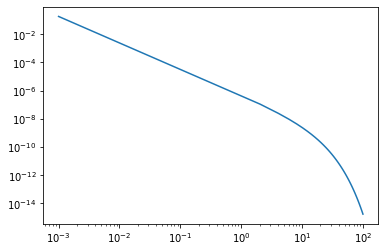

In [41]:
#Plot of the function
#xvals = np.linspace(0.001,100)
#plt.plot(xvals,[my_pdf(x) for x in xvals])
#plt.xscale('log')
#plt.yscale('log')
#plt.show()

In [200]:
#Sampling N luminosities from the given probability function (normalized and inverted) and association with random z
lx = itsample.sample(my_pdf, N, 0.001, 100)
#plt.hist(lx)
redshift = np.random.uniform(0.01, 2., size=(N))
with open('lx_z.txt', 'w') as f:
    writer = csv.writer(f, delimiter=" ")
    #writer.writerow(('Lx', 'redshift')) #not necessary, just file header
    writer.writerows(zip(lx,redshift))

In [31]:
#From luminosity to flux
#data=np.loadtxt('xray_z.txt')
#cosmo = FlatLambdaCDM(H0=71, Om0=0.3)
#print('Using Flat LmbdaCDM H0=0.71 Om0=0.3')
#xlum=data[:,0]
#z=data[:,1]
#dist = cosmo.luminosity_distance(z).value # in Mpc
#flux=(xlum*1e+44)/(4*math.pi*(dist*3.086e+24)**2)
#print(flux)

In [32]:
#Application of the flux limitations and association with random radio luminosity from uniform distribution
#limit = 2e-15 #erg s-1 cm-2
#with open('finaldata.txt', 'a') as f:
# for i,x in enumerate(flux):
#  if flux[i] > limit:
#   radio = np.random.uniform(1e-4, 100)
#   writer = csv.writer(f, delimiter=" ")
#   writer.writerow([lx[i], radio, redshift[i]])
#   #print(lx[i], radio, redshift[i])

In [201]:
#From luminosity to flux
data=np.loadtxt('lx_z.txt')
cosmo = FlatLambdaCDM(H0=71, Om0=0.3)
#print('Using Flat LmbdaCDM H0=0.71 Om0=0.3')
xlum=data[:,0]
z=data[:,1]
dist = cosmo.luminosity_distance(z).value # in Mpc
flux=(xlum*1e+44)/(4*math.pi*(dist*3.086e+24)**2)
#print(flux)

limit = 2e-15 #erg s-1 cm-2
limitradio=36e-6*1e-23

with open('simulation.txt', 'a') as f:
 for i,x in enumerate(flux):
  if flux[i] > limit:
    radio = np.random.uniform(27., 35.)
    fluxr=(10**radio)/(4*math.pi*(dist[i]*3.086e+24)**2)
    if fluxr > limitradio:
      writer = csv.writer(f, delimiter=" ")
      writer.writerow([lx[i], radio, redshift[i]])
    #if fluxr < limitradio:
    #  print(flux[i], fluxr, dist[i], lx[i], radio, redshift[i])

1.3924005963087144e-13 4.477538798457844e-30 2718.4722572394317 1.2314469816975286 27.597690875762375 0.4888405588455341
2.9912513233879434e-14 7.912597377736488e-29 3736.528571144806 0.49979421626441023 29.121257390078096 0.6360833394819476
6.118762450484904e-13 3.3995153043658915e-29 1403.5936966931572 1.4426072774882477 27.903901526558755 0.2781926835430062
7.257874950792601e-15 3.7131535833410727e-31 9528.376721158545 0.7885859363113434 27.60578245917174 1.3598325585139595
4.814382609777107e-14 6.367320087366243e-29 2153.168839740007 0.2671151258983452 28.54811456234155 0.4018342144302809
1.6071673325583608e-14 2.5791602142316687e-28 4461.794275171445 0.3828969329678391 29.788499112124043 0.7354743577308491
4.2823471909141844e-15 3.2769223916190654e-30 9973.756234094384 0.509801467546204 28.59118536252189 1.411036237955617
4.262986850374098e-15 1.5775475313785387e-28 9625.75688889134 0.47269986482000015 30.242853938453788 1.3710640739462396
1.4858130208038844e-14 6.519255974825506e